In [1]:
import time
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

## 读取数据集

第一行解释：定义一个数据转换规则，图像传入一般形状是（高，宽，通道数）（这里的通道数代表颜色信息，1代表黑白图，3代表彩色图，4则是在彩色图基础上加了一个透明度的概念）至于，每个像素点怎么表示，灰度图8位二进制，0是纯黑，255是纯白，彩色图，每张用3个8二进制分别代表三原色组成度，至于4的话，就是再加一个8位表示不透明度罢了

Fashion-MNIST？这是一个替代经典 MNIST 手写数字的数据集。它包含了 10 种不同类型的服装（如 T恤、裤子、裙子、运动鞋等）的黑白像素图。每张图片的分辨率极小，只有 $28 \times 28$ 像素，单通道（灰度图，所以 $C=1$）。

root="./data"：指定数据存放的文件夹。如果当前目录下没有一个叫 data 的文件夹，PyTorch 会自动创建它。

train=True：机器学习需要把数据分为两批。一批用来让网络“学习”（训练集）设置 True 代表我们现在要构建的是训练集。

transform=trans：这是一个“钩子”或回调配置。它告诉系统：“以后只要有人从这个数据集里拿图片，你必须先用我刚才定义的 trans（即 ToTensor()）把图片加工成 Tensor 浮点数，再交出来。”

download=True：执行时，程序会先去 ./data 目录里找有没有下好的文件。如果有，直接跳过；如果没有，它会自动连接官方服务器把压缩包下载下来。



In [2]:
# 把 PIL 图片转成 PyTorch Tensor
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=trans,
    download=True
)

mnist_test = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=trans,
    download=True
)

print(len(mnist_train))  # 60000
print(len(mnist_test))   # 10000

60000
10000


## 看一张图片情况

In [3]:
image, label = mnist_train[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([1, 28, 28])
9


## 标签编号转文字
if的那一步，由于label类型未知，若是tensor高维python原生语法不好遍历，调用内部判别函数，如果是tensor就转化成列表类型方便遍历

In [4]:
def get_fashion_mnist_labels(labels):
    text_labels = [
        "t-shirt",
        "trouser",
        "pullover",
        "dress",
        "coat",
        "sandal",
        "shirt",
        "sneaker",
        "bag",
        "ankle boot"
    ]
    if isinstance(labels, torch.Tensor):
        labels = labels.tolist()
    return [text_labels[int(i)] for i in labels]

## 显示图片函数

In [5]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """显示一批图片"""
    figsize = (num_cols * scale, num_rows * scale)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    # 保证 axes 是一维数组，方便遍历
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        # 如果是 Tensor，转成 numpy
        if isinstance(img, torch.Tensor):
            img = img.squeeze().numpy()#把长度位1的通道维删了，然后转成numpy数组
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

## 显示前18张图片
data.DataLoader(mnist_train, batch_size=18)作用：将之前加载的 mnist_train 数据集包装成一个数据加载器（DataLoader）。机制：由于机器学习不能一次性把几万张图扔进网络，需要分批处理。

iter(...)作用：将 DataLoader 对象转换成一个 Python 迭代器（Iterator）。机制：
DataLoader 本身不支持直接用索引或直接读取，必须先用 iter() 将其激活为一个可以流式按顺序往外吐数据的“传送带”。

next(...)作用：从迭代器（传送带）中强行抓取第一个批次的数据。数据解包（Unpacking）：抓取出来的 batch 包含两部分，通过 X, y = 赋值分别解包：X：存储图片的张量。其形状（Shape）为 $[18, 1, 28, 28]$，代表 18 张图片、每张图 1 个通道、高 28 像素、宽 28 像素。y：存储标签的张量。其形状为 $[18]$，里面包含 18 个 $0 \sim 9$ 的整数，对应这 18 张图分别是什么衣服。

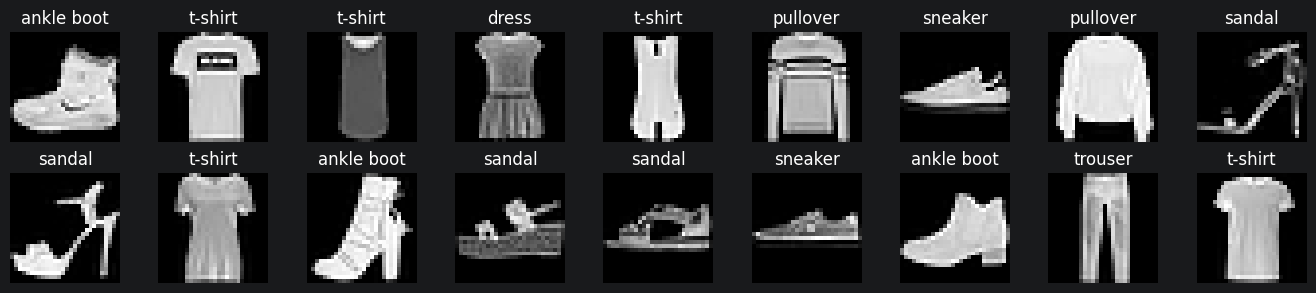

In [6]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(
    X,
    num_rows=2,
    num_cols=9,
    titles=get_fashion_mnist_labels(y)
)

## 读取小批量数据
num_workers=0：指定使用几条子线程来异步读取数据。0 代表仅使用主进程进行数据读取，不开启多进程。

In [7]:
batch_size = 256
train_iter = data.DataLoader(
    mnist_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)
test_iter = data.DataLoader(
    mnist_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

## 看一个小批量的形状

In [8]:
for X, y in train_iter:
    print(X.shape)
    print(y.shape)
    break

torch.Size([256, 1, 28, 28])
torch.Size([256])


## 测试读取速度

In [9]:
start = time.perf_counter()#记录当前系统时间戳
for X, y in train_iter:
    pass#空操作，代表遍历和转化后什么也不干
end = time.perf_counter()
print(f"{end - start:.2f} sec")

3.44 sec


## 整合成函数
5-6 如果resize有值就往里面放个resize转换器

7 还是必须填的转换器

8 将列表打包为一个可执行的对象，transform然后调用

In [10]:
def get_dataloader_workers():
    return 0
def load_data_fashion_mnist(batch_size, resize=None):
    trans_list = []
    if resize:
        trans_list.append(transforms.Resize(resize))
    trans_list.append(transforms.ToTensor())
    trans = transforms.Compose(trans_list)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="./data",
        train=True,
        transform=trans,
        download=True
    )
    mnist_test = torchvision.datasets.FashionMNIST(
        root="./data",
        train=False,
        transform=trans,
        download=True
    )
    train_iter = data.DataLoader(
        mnist_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=get_dataloader_workers()
    )
    test_iter = data.DataLoader(
        mnist_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=get_dataloader_workers()
    )
    return train_iter, test_iter